--- Step 1: Loading California Housing Data ---
Dataset Shape: (20640, 9)
Missing Values: 0


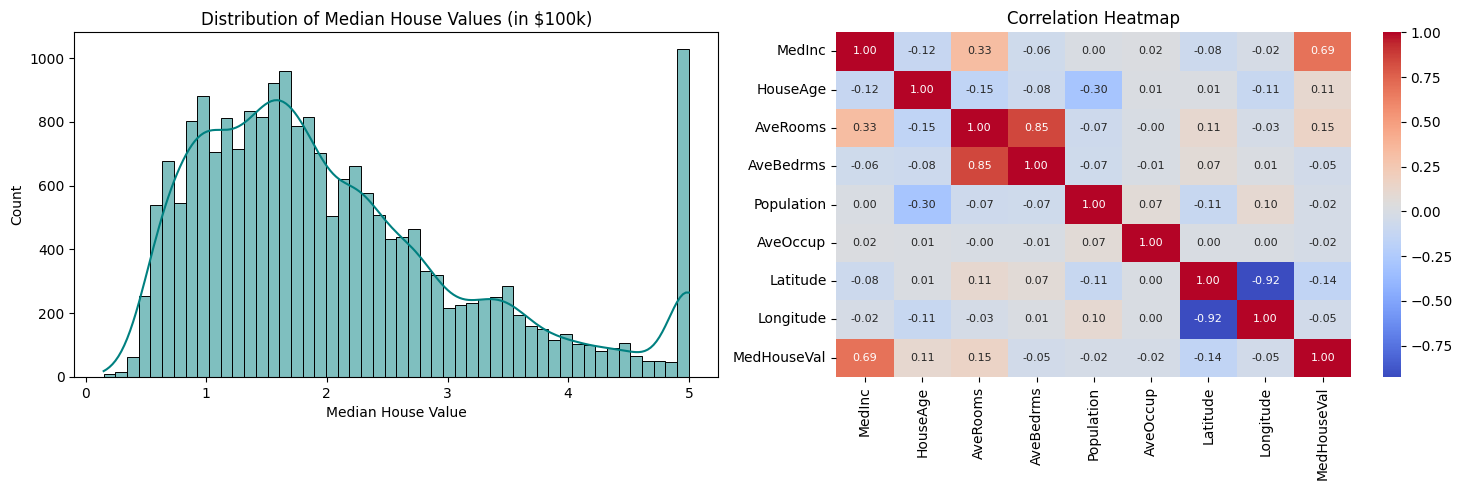


--- Step 2: Baseline Linear Regression ---
Metrics for Linear Regression (Test Set):
  MAE:  0.5332
  RMSE: 0.7456
  R^2:  0.5758

--- Steps 3 & 4: K-Fold Cross-Validation ---


,Model,Mean CV R^2,Std CV R^2
3,XGBoost,0.825595,0.004851
2,Random Forest,0.802550,0.006510
0,Linear Regression,0.611457,0.012359
1,Decision Tree,0.596149,0.025389



--- Step 5: Tuning Random Forest with GridSearchCV ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters found: {'max_depth': 20, 'n_estimators': 100}

--- Steps 6 & 7: Feature Importance & Final Test Comparison ---
--- Final Test Set Results ---
Metrics for Baseline Linear Regression:
  MAE:  0.5332
  RMSE: 0.7456
  R^2:  0.5758

Metrics for Tuned Random Forest:
  MAE:  0.3278
  RMSE: 0.5057
  R^2:  0.8049

Metrics for XGBoost:
  MAE:  0.3155
  RMSE: 0.4767
  R^2:  0.8266



C:\Users\PMLS\AppData\Local\Temp\ipykernel_7572\3814298492.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


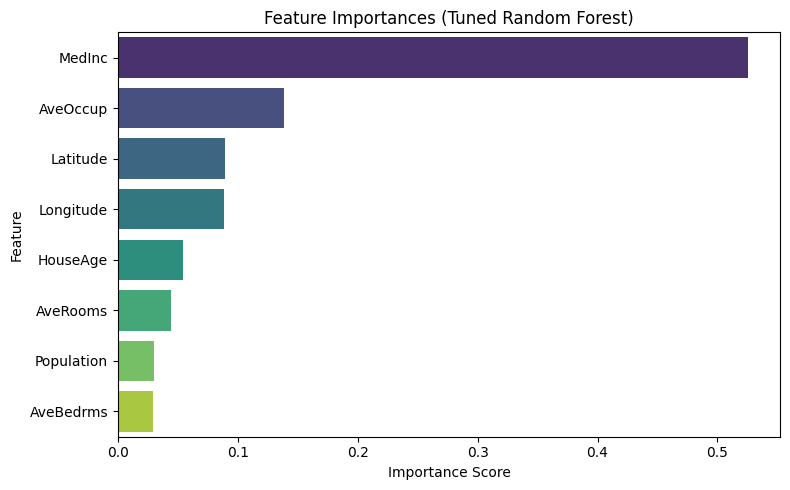

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn & XGBoost Imports
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ==========================================
# Step 1: Prepare and Explore the Dataset
# ==========================================
print("--- Step 1: Loading California Housing Data ---")
# Note: This might take a few seconds to download the first time you run it!
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target # Target: Median house value in 100,000s

print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Target Distribution
sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Median House Values (in $100k)')
axes[0].set_xlabel('Median House Value')

# Plot 2: Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], annot_kws={"size": 8})
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# ==========================================
# Step 2: Set up Validation & Baseline Model
# ==========================================
print("\n--- Step 2: Baseline Linear Regression ---")
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 80/20 Split (No stratify here because it's a regression task, not classification!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Metrics Function
def print_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"Metrics for {model_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R^2:  {r2:.4f}\n")

print_metrics(y_test, y_pred_lr, "Linear Regression (Test Set)")

# ==========================================
# Step 3 & 4: Cross-Validation & Non-Linear Models
# ==========================================
print("--- Steps 3 & 4: K-Fold Cross-Validation ---")
# We define a 5-fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42), # Kept at 50 for speed
    "XGBoost": XGBRegressor(n_estimators=50, random_state=42, objective='reg:squarederror')
}

cv_results = []
for name, model in models.items():
    # We use R^2 as the scoring metric for CV
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    cv_results.append({
        "Model": name,
        "Mean CV R^2": scores.mean(),
        "Std CV R^2": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values(by="Mean CV R^2", ascending=False)
display(cv_df)

# ==========================================
# Step 5: Hyperparameter Tuning (GridSearchCV)
# ==========================================
print("\n--- Step 5: Tuning Random Forest with GridSearchCV ---")
# We define a small grid so it evaluates relatively quickly
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

rf_grid = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, # 3-fold CV to save time 
    scoring='r2', 
    n_jobs=-1, # Uses all your computer's CPU cores to run faster!
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)
print(f"\nBest Parameters found: {grid_search.best_params_}")

# Extract the best model from the grid search
best_rf = grid_search.best_estimator_

# ==========================================
# Step 6 & 7: Feature Importance & Final Evaluation
# ==========================================
print("\n--- Steps 6 & 7: Feature Importance & Final Test Comparison ---")

# Evaluate best RF and XGBoost on the final TEST set
y_pred_best_rf = best_rf.predict(X_test_scaled)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print("--- Final Test Set Results ---")
print_metrics(y_test, y_pred_lr, "Baseline Linear Regression")
print_metrics(y_test, y_pred_best_rf, "Tuned Random Forest")
print_metrics(y_test, y_pred_xgb, "XGBoost")

# Plot Feature Importances from the Tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()